## Sustainable Operations Environment

This environment simulates a simple production system.

At each step, the agent decides how much to produce. The goal is to meet demand while reducing energy use, carbon emissions, and machine wear.

The environment includes:
- Inventory (how much is stored)
- Demand (customer needs)
- Energy price
- Carbon intensity (how "dirty" the electricity is)
- Machine health

The agent receives a reward based on good performance:
- Positive for serving demand
- Negative for energy use, emissions, and unmet demand

### Environment setup

In [1]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class SustainableOperationsEnv(gym.Env):
    def __init__(self, max_steps=50):
        super().__init__()

        self.max_steps = max_steps

        # Observation space: 6 values normalized between 0 and 1
        self.observation_space = spaces.Box(
            low=np.zeros(6, dtype=np.float32),
            high=np.ones(6, dtype=np.float32),
            dtype=np.float32
        )

        # Action space: 4 discrete production levels
        self.action_space = spaces.Discrete(4)

        # Map actions to production amounts
        self.production_levels = [0, 10, 20, 30]

        self.reset()

    def _sample_demand(self):
        # Random demand between 10 and 40
        return np.random.uniform(10, 40)

    def _sample_energy_price(self):
        # Random energy price between 0.2 and 1.0
        return np.random.uniform(0.2, 1.0)

    def _sample_carbon_intensity(self):
        # Random carbon intensity between 0.1 and 1.0
        return np.random.uniform(0.1, 1.0)

    def _get_obs(self):
        # Normalize all values to [0, 1]
        return np.array([
            self.inventory / 100.0,
            self.demand / 50.0,
            self.energy_price,
            self.carbon_intensity,
            self.machine_health,
            self.step_count / self.max_steps
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Reset time
        self.step_count = 0

        # Initial system state
        self.inventory = 20.0
        self.machine_health = 1.0

        # Sample external variables
        self.demand = self._sample_demand()
        self.energy_price = self._sample_energy_price()
        self.carbon_intensity = self._sample_carbon_intensity()

        obs = self._get_obs()
        info = {}

        return obs, info

    def step(self, action):
        # Convert action to production amount
        production = self.production_levels[action]

        # Energy used depends on production
        energy_used = 0.5 * production + (2.0 if production > 0 else 0)

        # Machine wear increases with production
        wear_cost = 0.01 * production
        self.machine_health -= 0.002 * production
        self.machine_health = max(0.0, self.machine_health)

        # Add produced items to inventory
        self.inventory += production

        # Serve demand from inventory
        served_demand = min(self.inventory, self.demand)
        unmet_demand = self.demand - served_demand
        self.inventory -= served_demand

        # Carbon emissions depend on energy and carbon intensity
        carbon_emission = energy_used * self.carbon_intensity

        # Penalize too much inventory
        excess_inventory = max(0.0, self.inventory - 40.0)

        # Reward function
        reward = (
            2.0 * served_demand                 # reward for serving demand
            - 1.0 * energy_used * self.energy_price
            - 2.0 * carbon_emission
            - 4.0 * unmet_demand
            - 1.5 * wear_cost
            - 0.5 * excess_inventory
        )

        # Move to next step
        self.step_count += 1

        # Check if episode ends
        terminated = self.machine_health <= 0.2
        truncated = self.step_count >= self.max_steps

        # Sample new external conditions
        self.demand = self._sample_demand()
        self.energy_price = self._sample_energy_price()
        self.carbon_intensity = self._sample_carbon_intensity()

        obs = self._get_obs()

        # Extra info for debugging or analysis
        info = {
            "served_demand": served_demand,
            "unmet_demand": unmet_demand,
            "energy_used": energy_used,
            "carbon_emission": carbon_emission
        }

        return obs, reward, terminated, truncated, info

### Test the environment

Before training, we check that the environment works.

This cell runs a few random actions and prints the results.

In [2]:
env = SustainableOperationsEnv(max_steps=50)

obs, info = env.reset()
print("Initial observation:", obs)

for step in range(5):
    action = env.action_space.sample()  # random action
    next_obs, reward, terminated, truncated, info = env.step(action)

    print(f"Step {step+1}")
    print("Action:", action)
    print("Reward:", reward)
    print("Info:", info)
    print("-" * 40)

    if terminated or truncated:
        break

Initial observation: [0.2        0.740748   0.66431046 0.66879916 1.         0.        ]
Step 1
Action: 3
Reward: 39.59235155779653
Info: {'served_demand': 37.03740072066701, 'unmet_demand': 0.0, 'energy_used': 17.0, 'carbon_emission': 11.369586199879295}
----------------------------------------
Step 2
Action: 0
Reward: -55.49335763026423
Info: {'served_demand': 12.962599279332991, 'unmet_demand': 20.354639047232553, 'energy_used': 0.0, 'carbon_emission': 0.0}
----------------------------------------
Step 3
Action: 2
Reward: -3.752313945936595
Info: {'served_demand': 20.0, 'unmet_demand': 8.15780673312716, 'energy_used': 12.0, 'carbon_emission': 2.4140639822066667}
----------------------------------------
Step 4
Action: 3
Reward: 3.4308664106008946
Info: {'served_demand': 15.498085769336058, 'unmet_demand': 0.0, 'energy_used': 17.0, 'carbon_emission': 6.006497367373959}
----------------------------------------
Step 5
Action: 2
Reward: 30.430494562591715
Info: {'served_demand': 34.50191

### Define the DQN model and replay buffer

Now we create:
- a Q-network
- a replay buffer
- a DQN agent

The Q-network predicts one Q-value for each action.

In [3]:
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        # Simple neural network
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        # Return Q-values for all actions
        return self.net(x)

In [5]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        # Store past transitions
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # Save one transition
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Sample a random batch
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [6]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99):
        self.action_dim = action_dim
        self.gamma = gamma

        # Main Q-network
        self.q_net = QNetwork(state_dim, action_dim)

        # Target Q-network
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())

        # Optimizer and loss
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

        # Epsilon-greedy settings
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995

    def select_action(self, state, greedy=False):
        # Use random action during exploration
        if (not greedy) and (np.random.rand() < self.epsilon):
            return np.random.randint(self.action_dim)

        # Use best action from network
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            q_values = self.q_net(state_t)
            return torch.argmax(q_values, dim=1).item()

    def train_step(self, replay_buffer, batch_size=64):
        # Do nothing if buffer is too small
        if len(replay_buffer) < batch_size:
            return None

        states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

        # Convert batch to tensors
        states = torch.tensor(np.array(states), dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

        # Current Q-values
        q_values = self.q_net(states).gather(1, actions)

        # Target Q-values
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            targets = rewards + self.gamma * next_q_values * (1 - dones)

        # Compute loss
        loss = self.loss_fn(q_values, targets)

        # Update network
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target(self):
        # Copy weights to target network
        self.target_net.load_state_dict(self.q_net.state_dict())

    def decay_epsilon(self):
        # Reduce exploration over time
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

### Train the agent

This cell trains the agent on the environment.

We store:
- total reward per episode
- average loss
- epsilon value

In [7]:
env = SustainableOperationsEnv(max_steps=50)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(state_dim, action_dim, lr=1e-3, gamma=0.99)
buffer = ReplayBuffer(capacity=20000)

In [8]:
num_episodes = 1000
batch_size = 64
target_update_every = 10

episode_rewards = []
episode_losses = []
epsilon_values = []

In [9]:
for episode in range(num_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    losses = []

    while not done:
        # Select action
        action = agent.select_action(state)

        # Step in environment
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Store transition
        buffer.push(state, action, reward, next_state, done)

        # Train agent
        loss = agent.train_step(buffer, batch_size=batch_size)
        if loss is not None:
            losses.append(loss)

        # Move to next state
        state = next_state
        total_reward += reward

    # Update epsilon after each episode
    agent.decay_epsilon()

    # Update target network sometimes
    if episode % target_update_every == 0:
        agent.update_target()

    # Save training history
    episode_rewards.append(total_reward)
    episode_losses.append(np.mean(losses) if losses else 0.0)
    epsilon_values.append(agent.epsilon)

    # Print progress
    if (episode + 1) % 20 == 0:
        print(
            f"Episode {episode+1}/{num_episodes} | "
            f"Reward: {total_reward:.2f} | "
            f"Loss: {episode_losses[-1]:.4f} | "
            f"Epsilon: {agent.epsilon:.3f}"
        )

Episode 20/1000 | Reward: 290.47 | Loss: 1154.6396 | Epsilon: 0.905
Episode 40/1000 | Reward: -443.96 | Loss: 364.3046 | Epsilon: 0.818
Episode 60/1000 | Reward: 73.99 | Loss: 260.0031 | Epsilon: 0.740
Episode 80/1000 | Reward: 61.62 | Loss: 264.9962 | Epsilon: 0.670
Episode 100/1000 | Reward: 313.38 | Loss: 325.5923 | Epsilon: 0.606
Episode 120/1000 | Reward: 342.89 | Loss: 324.1883 | Epsilon: 0.548
Episode 140/1000 | Reward: 187.64 | Loss: 327.1451 | Epsilon: 0.496
Episode 160/1000 | Reward: 262.69 | Loss: 320.0898 | Epsilon: 0.448
Episode 180/1000 | Reward: 253.34 | Loss: 264.6485 | Epsilon: 0.406
Episode 200/1000 | Reward: 171.32 | Loss: 270.0936 | Epsilon: 0.367
Episode 220/1000 | Reward: 140.32 | Loss: 243.3481 | Epsilon: 0.332
Episode 240/1000 | Reward: 223.93 | Loss: 221.5751 | Epsilon: 0.300
Episode 260/1000 | Reward: 400.41 | Loss: 175.3055 | Epsilon: 0.272
Episode 280/1000 | Reward: 410.10 | Loss: 159.9331 | Epsilon: 0.246
Episode 300/1000 | Reward: 82.79 | Loss: 194.9974 | 

### Plot training results

Now we plot:
- reward per episode
- average loss
- epsilon decay

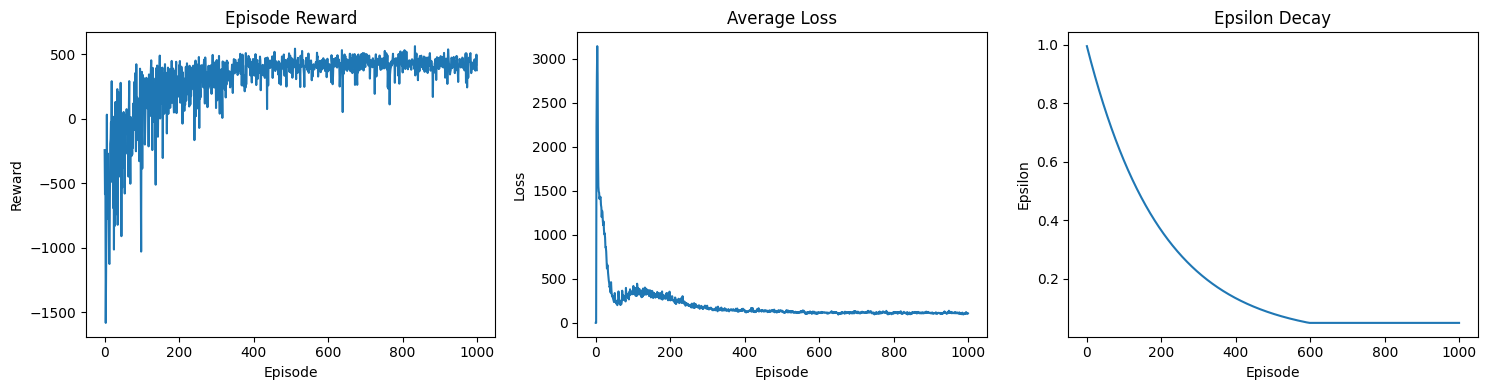

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot rewards
axes[0].plot(episode_rewards)
axes[0].set_title("Episode Reward")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")

# Plot loss
axes[1].plot(episode_losses)
axes[1].set_title("Average Loss")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Loss")

# Plot epsilon
axes[2].plot(epsilon_values)
axes[2].set_title("Epsilon Decay")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Epsilon")

# Adjust layout
plt.tight_layout()
plt.show()

### Evaluate the trained agent

In evaluation, we use greedy actions only.

This means the agent chooses the action with the highest predicted Q-value.

In [11]:
def evaluate_agent(env, agent, num_episodes=10):
    rewards = []
    served_list = []
    unmet_list = []
    energy_list = []
    carbon_list = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        total_served = 0
        total_unmet = 0
        total_energy = 0
        total_carbon = 0

        while not done:
            # Greedy action for evaluation
            action = agent.select_action(state, greedy=True)

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            total_served += info["served_demand"]
            total_unmet += info["unmet_demand"]
            total_energy += info["energy_used"]
            total_carbon += info["carbon_emission"]

            state = next_state

        rewards.append(total_reward)
        served_list.append(total_served)
        unmet_list.append(total_unmet)
        energy_list.append(total_energy)
        carbon_list.append(total_carbon)

    results = {
        "avg_reward": np.mean(rewards),
        "avg_served_demand": np.mean(served_list),
        "avg_unmet_demand": np.mean(unmet_list),
        "avg_energy_used": np.mean(energy_list),
        "avg_carbon_emission": np.mean(carbon_list),
    }

    return results

In [12]:
eval_results = evaluate_agent(env, agent, num_episodes=20)

for key, value in eval_results.items():
    print(f"{key}: {value:.2f}")

avg_reward: 460.92
avg_served_demand: 425.12
avg_unmet_demand: 1.37
avg_energy_used: 235.40
avg_carbon_emission: 121.12


### Run one example episode

This cell shows one full episode step by step.

It helps us understand what the trained agent is doing.

In [13]:
state, _ = env.reset()
done = False
step = 0

while not done:
    action = agent.select_action(state, greedy=True)
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    print(f"Step {step}")
    print(f"Action: {action} -> Production: {env.production_levels[action]}")
    print(f"Reward: {reward:.2f}")
    print(f"Demand served: {info['served_demand']:.2f}")
    print(f"Unmet demand: {info['unmet_demand']:.2f}")
    print(f"Energy used: {info['energy_used']:.2f}")
    print(f"Carbon emission: {info['carbon_emission']:.2f}")
    print("-" * 40)

    state = next_state
    step += 1

Step 0
Action: 3 -> Production: 30
Reward: 25.79
Demand served: 31.65
Unmet demand: 0.00
Energy used: 17.00
Carbon emission: 11.70
----------------------------------------
Step 1
Action: 1 -> Production: 10
Reward: 17.22
Demand served: 17.98
Unmet demand: 0.00
Energy used: 7.00
Carbon emission: 6.82
----------------------------------------
Step 2
Action: 3 -> Production: 30
Reward: 39.59
Demand served: 36.96
Unmet demand: 0.00
Energy used: 17.00
Carbon emission: 9.32
----------------------------------------
Step 3
Action: 3 -> Production: 30
Reward: -17.61
Demand served: 10.02
Unmet demand: 0.00
Energy used: 17.00
Carbon emission: 14.05
----------------------------------------
Step 4
Action: 3 -> Production: 30
Reward: 49.98
Demand served: 37.71
Unmet demand: 0.00
Energy used: 17.00
Carbon emission: 4.07
----------------------------------------
Step 5
Action: 3 -> Production: 30
Reward: 41.03
Demand served: 36.52
Unmet demand: 0.00
Energy used: 17.00
Carbon emission: 8.00
-------------